In [ ]:
Exam 1

Exam 1
Author: Kayce Johnson


In [32]:
# Package Imports - copy and paste
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

In [33]:
file_location = 'https://joannabieri.com/introdatascience/data/lego_sample.csv'
DF = pd.read_csv(file_location)
show(DF)


Loading ITables v2.6.2 from the internet... (need help?)


In [4]:
#Problem 1
#(a) There are 14 variables (columns) and 75 observations (rows)
#(b) Names of all the variables:
DF.keys()

Index(['item_number', 'set_name', 'theme', 'pieces', 'price', 'amazon_price',
       'year', 'ages', 'pages', 'minifigures', 'packaging', 'weight',
       'unique_pieces', 'size'],
      dtype='object')

In [ ]:
#(c) 
# item_number - numerical
# set_name - categorical 
# theme - categorical
# pieces - numerical
# price - numerical
# amazon_price - numerical
# year - numerical
# ages - categorical
# pages - numerical
# minifigures - numerical
# packaging - categorical
# weight - numerical
# unique_pieces - numerical
# size - categorical

In [8]:
DF.describe()

,item_number,pieces,price,amazon_price,year,pages,minifigures,unique_pieces
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,65.000000,75.000000
mean,37498.493333,196.453333,32.136667,39.393733,2019.053333,73.213333,2.615385,96.666667
std,20461.267542,213.914121,27.747263,33.301259,0.820239,76.949842,2.133749,89.471018
min,10859.000000,6.000000,4.990000,6.290000,2018.000000,1.000000,1.000000,5.000000
25%,10916.500000,37.000000,9.990000,17.980000,2018.000000,14.000000,1.000000,30.000000
50%,41378.000000,93.000000,19.990000,29.990000,2019.000000,44.000000,2.000000,61.000000
75%,60193.000000,323.500000,39.990000,53.935000,2020.000000,116.000000,3.000000,151.000000
max,60267.000000,897.000000,149.990000,184.990000,2020.000000,389.000000,15.000000,411.000000


In [ ]:
# I notice that there is a very high range of number of pieces per set - ranging from as few as 6 to as many as 897. With the average being nearly 200 (198.45). This tells me that there are nota s many high pieces sets since the average is well below half and the standard deviation is over 200 (213.9).
# I also see that there is a much smaller spread for pages. This is inersting ot think that you don't need that many more ages to descrive sets iwth higher piece counts and makes me wonder if larger sets (by piece count) necessarily means more complicated. There could be repetition that cuts down on page counts.
# I notice this data is only giving information on numerical data (of course), and although the item_number is a number, it doesn't make sense to think about it as a piece of numerical data, because they shoul be preserved in any alaysis. Similar for ear, although looking at averages makes more sense here.


In [10]:
relevant_columns = ['set_name', 'theme', 'ages', 'minifigures', 'size']
DF[relevant_columns]
# I did not include packaging type. Unless I was looking at the packaging specifically, it doesn't necessarily give me any information about the sets each package contains.


,set_name,theme,ages,minifigures,size
0,My First Ladybird,DUPLO®,Ages_1½-3,NaN,Large
1,My First Race Car,DUPLO®,Ages_1½-3,NaN,Large
2,My First Celebration,DUPLO®,Ages_1½-3,NaN,Large
3,Large Playground Brick Box,DUPLO®,Ages_2-5,2.0,Large
4,Farmers' Market,DUPLO®,Ages_2-5,3.0,Large
...,...,...,...,...,...
70,Monster Truck,City,Ages_5+,1.0,Small
71,Construction Bulldozer,City,Ages_4+,2.0,Small
72,Tuning Workshop,City,Ages_6+,7.0,Small
73,Ocean Exploration Ship,City,Ages_7+,8.0,Small


In [17]:
show(DF.value_counts('set_name'))
show(DF.value_counts('theme'))
show(DF.value_counts('ages'))
show(DF.value_counts('minifigures'))
show(DF.value_counts('size'))

Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [18]:
### There are many more small sets, which makes sense as many are geared towards younger ages. Also, there are a lot of categories of age ranges, but many of them overlap. It would be interesting to graph this and see what the spread of age range actual was, and how many sets were created for each age range, without the overlap.  



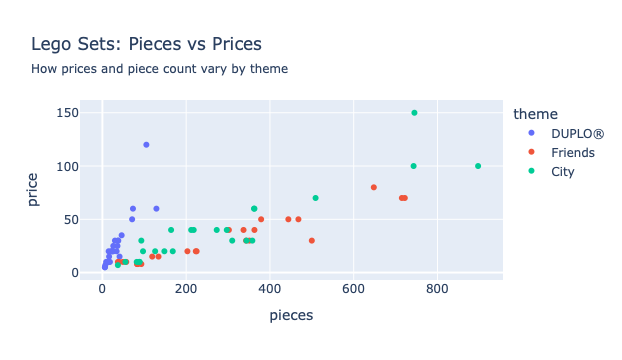

In [21]:
#Problem 3
#(a)
fig = px.scatter(DF,
                 x='pieces',
                 y='price',
                 color='theme',
                 title='Lego Sets: Pieces vs Prices',
                 subtitle='How prices and piece count vary by theme',
                 hover_data='set_name')
fig.show()

In [ ]:
#(b)
#The more expensive sets do have a positive correlation with more pieces. More so in the Friends and City themes, which makes sense since Duplo are geared towards younger children.

#The most expensive set is 'Ocean Exploration Set' at $149.99

# There is a difference in the themes. Sepcifically, DUPLO does not get much pricier even with their highest piece-count sets. This may be because they are geared towards the youngest children. Although city does have several more expensive pieces then Friends, there is a similar correlation in those two themes.



In [36]:
#Problem 4
#(a) 
DF['price_diff'] = DF['amazon_price'] - DF['price']
difference_columns = ['set_name', 'price_diff']
show(DF[difference_columns])
#Positive values mean that the price on Amazon is greater than the retail price.


Loading ITables v2.6.2 from the internet... (need help?)


In [30]:
#(b)
price_columns = ['theme', 'price_diff']
DF[price_columns].groupby('theme').describe()


price_diff                                                     
             count    mean        std    min   25%   50%    75%     max
theme                                                                  
City          25.0  5.3996  15.243677 -13.99 -4.01 -1.00  12.00   39.96
DUPLO®        25.0  7.3924  16.996152  -5.00 -2.00  0.00  11.01   69.00
Friends       25.0  8.9792  24.047927  -9.99 -0.04  3.96   8.94  115.00

In [ ]:
# There is the biggest swing of price different on the Friends set, as seen by the highest standard deviation.
# The best price difference is in the City collection, so the Amazon price may on average be better (lowest minimum and 50% still a negative value)
# There is not a great benefit to shopping on Amazon for legos- doing price checks is worthwhile since its not a guarantee the prices will be better, on average. In fact, the average is positie which means that in general, the legos cost more on Aamzon.
# Even though City has the highest priced item, the average is the lowest for the price difference, which is very interesting and not what I would expect.


In [ ]:
#(c)
fig = px.histogram(DF,
                  x=

fig.show()

In [43]:
#Probem 5
#(a)
price_columns = ['set_name', 'price']
DF_price_sorted = DF[price_columns].sort_values('price', ascending=False)
show(DF_price_sorted)

#Ocean Exploration Ship is the most expensive by retail price

lookup = 149.99
my_columns = DF.keys()
mask = DF['price']==lookup
show(DF[mask][my_columns])


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [46]:
#(b)
price_columns = ['set_name', 'amazon_price']
DF_amzprice_sorted = DF[price_columns].sort_values('amazon_price', ascending=False)
show(DF_amzprice_sorted)

# Friendship House is the most expensive by Amazon price

lookup = 184.99
my_columns = DF.keys()
mask2 = DF['amazon_price']==lookup
show(DF[mask2][my_columns])


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [55]:
 #(c)
mask3 = DF['price'] >100 
mask4 = DF['amazon_price'] >100
show(DF[mask3 | mask4])
#how to use or operator here?

Loading ITables v2.6.2 from the internet... (need help?)


In [60]:
#Problem 6
#(a)
maskyear = DF['year'].drop_duplicates()
show(maskyear)

Loading ITables v2.6.2 from the internet... (need help?)


In [65]:
my_columns = ['price', 'year']
show(DF[my_columns].groupby('year')['price'].mean())
my_amz_columns = ['amazon_price', 'year']
show(DF[my_amz_columns].groupby('year')['amazon_price'].mean())


Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [ ]:
#The average price has gone up significantly from 2018 to 2020, with no significant change from 2018 to 2019.
#Average Amazon price has done the inverse and decreased from 2018 to 2019 significantly, with an increase into 2020. Both are similar in 2020.f


In [69]:
#(b)
my_piececolumns = ['pieces', 'year']
show(DF[my_piececolumns].groupby('year')['pieces'].mean())


Loading ITables v2.6.2 from the internet... (need help?)


In [ ]:
#the number of pieces, on average, is increasing over the 3 years.


In [74]:
#(c)
mini_columns = ['set_name', 'minifigures']
show(DF[mini_columns].sort_values('minifigures', ascending=False))
#People-Pack Outdoor Adventures have the most minifigures

Loading ITables v2.6.2 from the internet... (need help?)


In [90]:
zero_minifigures = DF.groupby('minifigures')['minifigures'].value_counts()
zero_minifigures = zero_minifigures.reset_index().rename(columns={"index": "value", 0: "count"})
show(zero_minifigures)
show(zero_minifigures.sum())



Loading ITables v2.6.2 from the internet... (need help?)


Loading ITables v2.6.2 from the internet... (need help?)


In [89]:
#Since there are 75 total observations, and 65 have at least one mini figure, then 10 have zero or none


In [ ]:
#Problem 7
#look at uniue data in the age coloumn and mask the ones that include 6 year olds then compare

